# Right-Censored HAL/TMLE Initializer Comparison

This notebook compares four right-censored survival initial estimators under the shared univariate HAL setup:

- `M1`: IPCW-HAL tuned by observed-data log-likelihood
- `M2`: IPCW-HAL tuned by IPCW validation loss
- `M3`: observed-data HAL-MLE via FISTA
- `M4`: observed-data HAL-MLE via FPGD

It uses the new experiment helpers in `haldensity.censoring.right.comparison` so the same code path can be reused for both one-dataset diagnostics and small Monte Carlo summaries.

The defaults below are intentionally modest so the notebook stays runnable as a prototype. Increase `N_TRIALS` and `N_REPS` once the workflow looks right.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from IPython.display import display
from tqdm.auto import tqdm

from haldensity.censoring.right.comparison import (
    run_right_censored_initial_estimator_experiment,
    simulate_beta_uniform_right_censored,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 20260317
N = 120
TARGET_TIMES = np.array([0.2, 0.4, 0.6, 0.8])
CV_FOLDS = 5
N_TRIALS = 30
N_GRID_POINTS = 200
N_REPS = 10
N_WORKERS = 8  # set to 1 for sequential
PARALLEL_BACKEND = "processes"  # "processes" shows separate worker processes

METHOD_PARAM_OVERRIDES = {
    "M1": {"basis_order": [0, 1], "norm_constraint": {"low": 2.0, "high": 25.0, "log": True}},
    "M2": {"basis_order": [0, 1], "norm_constraint": {"low": 2.0, "high": 25.0, "log": True}},
    "M3": {"basis_order": [0, 1], "lam": {"low": 1e-3, "high": 2e-1, "log": True}},
    "M4": {"basis_order": [0, 1], "norm_constraint": {"low": 2.0, "high": 25.0, "log": True}},
}

INIT_TUNER_KWARGS = {
    "silent": True,
    "use_conservative_adjustment": False,
}

FISTA_KWARGS = {
    "n_iterations": 2000,
    "ll_change_tol": 1e-4,
    "history_every": 25,
}

FPGD_KWARGS = {
    "n_iterations": 2000,
    "ll_change_tol": 1e-4,
    "learning_rate": 0.1,
    "history_every": 25,
}

TMLE_KWARGS = {
    "store_pointwise_arrays": False,
}

In [3]:
sim = simulate_beta_uniform_right_censored(n=N, seed=SEED)
observed_data = sim["observed_data"]
truth = sim["truth"]

single_result = run_right_censored_initial_estimator_experiment(
    observed_data,
    truth=truth,
    target_times=TARGET_TIMES,
    cv_folds=CV_FOLDS,
    n_trials=N_TRIALS,
    random_state=SEED,
    n_grid_points=N_GRID_POINTS,
    method_param_overrides=METHOD_PARAM_OVERRIDES,
    init_tuner_kwargs=INIT_TUNER_KWARGS,
    fista_kwargs=FISTA_KWARGS,
    fpgd_kwargs=FPGD_KWARGS,
    run_tmle=True,
    tmle_kwargs=TMLE_KWARGS,
)

print(f"n={len(observed_data)}, uncensored={int(observed_data['Delta'].sum())}, censored={int((1 - observed_data['Delta']).sum())}")
print(f"censoring rate={1.0 - observed_data['Delta'].mean():.1%}")

display(observed_data.head())

display(
    single_result["initial_summary"].sort_values("method").reset_index(drop=True)
)

display(
    single_result["initial_pointwise_summary"].sort_values(["t0", "method"]).reset_index(drop=True)
)

display(
    single_result["tmle_summary"].sort_values(["t0", "method"]).reset_index(drop=True)
)

n=120, uncensored=58, censored=62
censoring rate=51.7%


,T,Delta
0,0.137284,0
1,0.442501,0
2,0.144318,0
3,0.661531,0
4,0.335899,0


,method,label,observed_loglik,ipcw_loglik,runtime_seconds,n_selected_knots,n_iterations_run,converged,final_objective_value,final_step,final_learning_rate,best_params,validation_metric,integrated_density_error,integrated_survival_error,mean_pointwise_survival_error,max_pointwise_survival_error
0,M1,IPCW-HAL tuned by observed-data log-likelihood,-18.969145,30.835178,1.917090,7,NaN,None,NaN,NaN,NaN,"{'basis_order': 1, 'norm_constraint': 24.79797...",observed_loglik,0.227800,0.033818,0.035833,0.079738
1,M2,IPCW-HAL tuned by IPCW validation loss,-26.899373,6.372661,1.942944,3,NaN,None,NaN,NaN,NaN,"{'basis_order': 1, 'norm_constraint': 2.001618...",ipcw_loglik,0.377637,0.061743,0.070244,0.095041
2,M3,Observed-data HAL-MLE via FISTA,-19.431331,18.052032,13.854455,20,139.0,True,19.218059,0.026907,NaN,"{'basis_order': 1, 'lam': 0.19662459772359853}",observed_loglik,0.180562,0.044314,0.050467,0.074391
3,M4,Observed-data HAL-MLE via FPGD,-20.648943,13.503186,7.296623,17,254.0,True,20.492817,NaN,0.05,"{'basis_order': 1, 'norm_constraint': 7.464026...",observed_loglik,0.246893,0.053359,0.061725,0.091655


,method,label,t0,psi_init,truth_survival,abs_error,squared_error
0,M1,IPCW-HAL tuned by observed-data log-likelihood,0.2,0.878802,0.888675,0.009873,9.748321e-05
1,M2,IPCW-HAL tuned by IPCW validation loss,0.2,0.793634,0.888675,0.095041,9.032772e-03
2,M3,Observed-data HAL-MLE via FISTA,0.2,0.895514,0.888675,0.006839,4.677385e-05
3,M4,Observed-data HAL-MLE via FPGD,0.2,0.878753,0.888675,0.009922,9.844957e-05
4,M1,IPCW-HAL tuned by observed-data log-likelihood,0.4,0.657071,0.603920,0.053151,2.825070e-03
5,M2,IPCW-HAL tuned by IPCW validation loss,0.4,0.579982,0.603920,0.023938,5.730164e-04
6,M3,Observed-data HAL-MLE via FISTA,0.4,0.662127,0.603920,0.058207,3.388077e-03
7,M4,Observed-data HAL-MLE via FPGD,0.4,0.663175,0.603920,0.059255,3.511132e-03
8,M1,IPCW-HAL tuned by observed-data log-likelihood,0.6,0.365003,0.285265,0.079738,6.358144e-03
9,M2,IPCW-HAL tuned by IPCW validation loss,0.6,0.358788,0.285265,0.073523,5.405573e-03


,t0,psi_init,psi_star,epsilon,estimand_variance,standard_error,ci_lower,ci_upper,score_at_zero,score_at_solution,objective_at_solution,eif_mean,solve_method,converged,target_grid_augmented_with_t0,method,label,truth_survival,plugin_bias,targeted_bias,plugin_squared_error,targeted_squared_error,plugin_abs_error,targeted_abs_error,epsilon_abs
0,0.2,0.878806,0.909127,0.297600,0.000764,0.027635,0.854961,0.963292,3.631664,2.220446e-15,-18.236170,1.850372e-17,score_root,True,True,M1,IPCW-HAL tuned by observed-data log-likelihood,0.888675,-0.009868,0.020452,9.738607e-05,0.000418,0.009868,0.020452,0.297600
1,0.2,0.793634,0.909255,0.892777,0.000768,0.027714,0.854935,0.963576,13.840298,4.440892e-16,-21.424708,3.700743e-18,score_root,True,True,M2,IPCW-HAL tuned by IPCW validation loss,0.888675,-0.095041,0.020580,9.032702e-03,0.000424,0.095041,0.020580,0.892777
2,0.2,0.895520,0.909112,0.142299,0.000763,0.027618,0.854981,0.963243,1.628364,1.998401e-15,-19.117846,1.665335e-17,score_root,True,True,M3,Observed-data HAL-MLE via FISTA,0.888675,0.006845,0.020437,4.685835e-05,0.000418,0.006845,0.020437,0.142299
3,0.2,0.878757,0.909127,0.298199,0.000764,0.027635,0.854961,0.963292,3.637458,-2.886580e-15,-19.985372,-2.405483e-17,score_root,True,True,M4,Observed-data HAL-MLE via FPGD,0.888675,-0.009918,0.020452,9.835794e-05,0.000418,0.009918,0.020452,0.298199
4,0.4,0.657073,0.630919,-0.083660,0.002745,0.052389,0.528238,0.733601,-3.086006,-2.309264e-14,-18.624088,-1.924387e-16,score_root,True,True,M1,IPCW-HAL tuned by observed-data log-likelihood,0.603920,0.053153,0.026999,2.825195e-03,0.000729,0.053153,0.026999,0.083660
5,0.4,0.579983,0.632716,0.168732,0.002806,0.052976,0.528883,0.736548,6.098125,-3.463896e-14,-26.401442,-2.886580e-16,score_root,True,True,M2,IPCW-HAL tuned by IPCW validation loss,0.603920,-0.023937,0.028795,5.729891e-04,0.000829,0.023937,0.028795,0.168732
6,0.4,0.662126,0.631129,-0.098087,0.002739,0.052336,0.528551,0.733708,-3.681371,-5.950795e-14,-19.049642,-4.958996e-16,score_root,True,True,M3,Observed-data HAL-MLE via FISTA,0.603920,0.058206,0.027209,3.387943e-03,0.000740,0.058206,0.027209,0.098087
7,0.4,0.663184,0.630805,-0.104271,0.002741,0.052358,0.528182,0.733427,-3.817978,-6.128431e-14,-20.304578,-5.107026e-16,score_root,True,True,M4,Observed-data HAL-MLE via FPGD,0.603920,0.059264,0.026885,3.512211e-03,0.000723,0.059264,0.026885,0.104271
8,0.6,0.365004,0.363658,-0.003130,0.003565,0.059710,0.246625,0.480690,-0.157995,-1.340172e-11,-18.753564,-1.116810e-13,score_root,True,True,M1,IPCW-HAL tuned by observed-data log-likelihood,0.285265,0.079739,0.078393,6.358307e-03,0.006145,0.079739,0.078393,0.003130
9,0.6,0.358788,0.362819,0.009993,0.003594,0.059953,0.245311,0.480327,0.429138,2.620126e-14,-26.911305,2.183439e-16,score_root,True,True,M2,IPCW-HAL tuned by IPCW validation loss,0.285265,0.073523,0.077554,5.405660e-03,0.006015,0.073523,0.077554,0.009993


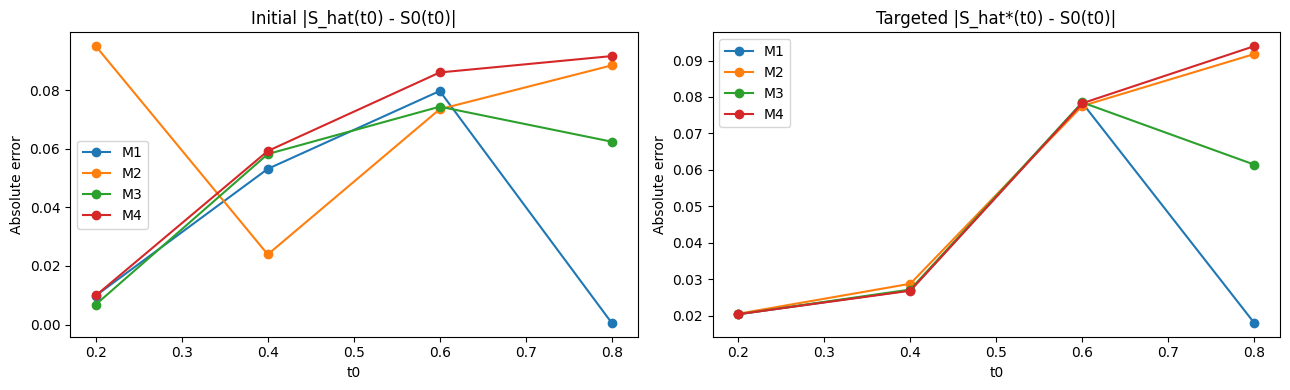

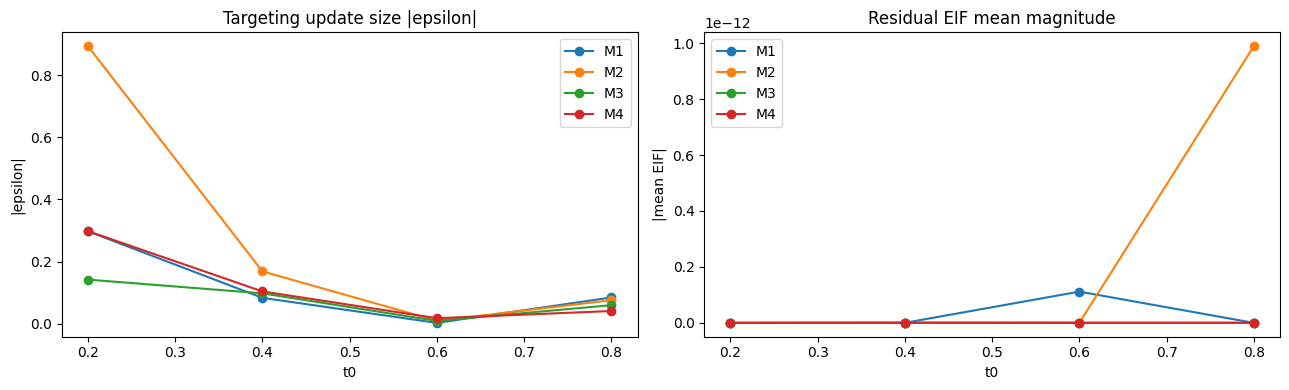

In [4]:
initial_pointwise = single_result["initial_pointwise_summary"].copy()
tmle_summary = single_result["tmle_summary"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

for method, method_df in initial_pointwise.groupby("method"):
    axes[0].plot(method_df["t0"], method_df["abs_error"], marker="o", label=method)
axes[0].set_title("Initial |S_hat(t0) - S0(t0)|")
axes[0].set_xlabel("t0")
axes[0].set_ylabel("Absolute error")
axes[0].legend()

for method, method_df in tmle_summary.groupby("method"):
    axes[1].plot(method_df["t0"], method_df["targeted_abs_error"], marker="o", label=method)
axes[1].set_title("Targeted |S_hat*(t0) - S0(t0)|")
axes[1].set_xlabel("t0")
axes[1].set_ylabel("Absolute error")
axes[1].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for method, method_df in tmle_summary.groupby("method"):
    axes[0].plot(method_df["t0"], method_df["epsilon_abs"], marker="o", label=method)
axes[0].set_title("Targeting update size |epsilon|")
axes[0].set_xlabel("t0")
axes[0].set_ylabel("|epsilon|")
axes[0].legend()

for method, method_df in tmle_summary.groupby("method"):
    axes[1].plot(method_df["t0"], np.abs(method_df["eif_mean"]), marker="o", label=method)
axes[1].set_title("Residual EIF mean magnitude")
axes[1].set_xlabel("t0")
axes[1].set_ylabel("|mean EIF|")
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
def run_one_rep(rep_seed: int):
    sim_rep = simulate_beta_uniform_right_censored(n=N, seed=rep_seed)
    rep_result = run_right_censored_initial_estimator_experiment(
        sim_rep["observed_data"],
        truth=sim_rep["truth"],
        target_times=TARGET_TIMES,
        cv_folds=CV_FOLDS,
        n_trials=N_TRIALS,
        random_state=rep_seed,
        n_grid_points=N_GRID_POINTS,
        method_param_overrides=METHOD_PARAM_OVERRIDES,
        init_tuner_kwargs=INIT_TUNER_KWARGS,
        fista_kwargs=FISTA_KWARGS,
        fpgd_kwargs=FPGD_KWARGS,
        run_tmle=True,
        tmle_kwargs=TMLE_KWARGS,
    )

    init_df = rep_result["initial_summary"].copy()
    init_df["rep"] = rep_seed

    tmle_df = rep_result["tmle_summary"].copy()
    tmle_df["rep"] = rep_seed
    tmle_df["plugin_rmse_component"] = tmle_df["plugin_squared_error"]
    tmle_df["targeted_rmse_component"] = tmle_df["targeted_squared_error"]
    return init_df, tmle_df


if N_REPS <= 0:
    raise ValueError("N_REPS must be positive")

rep_indices = list(range(N_REPS))
rep_seeds = [SEED + 1000 + rep for rep in rep_indices]

if N_WORKERS == 1:
    rep_results = [run_one_rep(rep_seed) for rep_seed in tqdm(rep_seeds, desc="Monte Carlo reps")]
else:
    # Use process workers so Activity Monitor shows separate Python jobs.
    if PARALLEL_BACKEND == "processes":
        rep_results = Parallel(n_jobs=N_WORKERS, prefer="processes", verbose=10)(
            delayed(run_one_rep)(rep_seed) for rep_seed in rep_seeds
        )
    else:
        rep_results = Parallel(n_jobs=N_WORKERS, prefer="threads", verbose=10)(
            delayed(run_one_rep)(rep_seed) for rep_seed in rep_seeds
        )

mc_init_parts = [res[0] for res in rep_results]
mc_tmle_parts = [res[1] for res in rep_results]

mc_init = pd.concat(mc_init_parts, ignore_index=True)
mc_tmle = pd.concat(mc_tmle_parts, ignore_index=True)

init_mc_summary = (
    mc_init.groupby("method", as_index=False)
    .agg(
        mean_observed_loglik=("observed_loglik", "mean"),
        mean_ipcw_loglik=("ipcw_loglik", "mean"),
        mean_integrated_density_error=("integrated_density_error", "mean"),
        mean_integrated_survival_error=("integrated_survival_error", "mean"),
        mean_runtime_seconds=("runtime_seconds", "mean"),
    )
    .set_index("method")
    .sort_index()
    .reset_index()
)

tmle_mc_summary = (
    mc_tmle.groupby(["method", "t0"], as_index=False)
    .agg(
        plugin_mean=("psi_init", "mean"),
        targeted_mean=("psi_star", "mean"),
        truth_survival=("truth_survival", "mean"),
        plugin_bias=("plugin_bias", "mean"),
        targeted_bias=("targeted_bias", "mean"),
        plugin_rmse=("plugin_rmse_component", lambda x: float(np.sqrt(np.mean(x)))),
        targeted_rmse=("targeted_rmse_component", lambda x: float(np.sqrt(np.mean(x)))),
        mean_standard_error=("standard_error", "mean"),
        mean_abs_score_at_solution=("score_at_solution", lambda x: float(np.mean(np.abs(x)))),
        mean_abs_eif_mean=("eif_mean", lambda x: float(np.mean(np.abs(x)))),
        mean_abs_epsilon=("epsilon_abs", "mean"),
    )
    .set_index(["t0", "method"])
    .sort_index()
    .reset_index()
)

display(init_mc_summary)
display(tmle_mc_summary)

init_by_method = init_mc_summary.set_index("method")
m1_vs_m2 = init_by_method.reindex(["M1", "M2"])
m3_vs_m4 = init_by_method.reindex(["M3", "M4"])

tmle_method_summary = (
    tmle_mc_summary.groupby("method", as_index=False)
    .agg(
        mean_plugin_rmse=("plugin_rmse", "mean"),
        mean_targeted_rmse=("targeted_rmse", "mean"),
        mean_abs_targeted_bias=("targeted_bias", lambda x: float(np.mean(np.abs(x)))),
        mean_abs_epsilon=("mean_abs_epsilon", "mean"),
    )
    .set_index("method")
    .sort_index()
    .reset_index()
)

display(tmle_method_summary)

print("IPCW tuning comparison (M1 vs M2):")
print(m1_vs_m2[["mean_observed_loglik", "mean_ipcw_loglik", "mean_integrated_survival_error"]])
print()
print("Observed-data optimizer comparison (M3 vs M4):")
print(m3_vs_m4[["mean_observed_loglik", "mean_integrated_survival_error", "mean_runtime_seconds"]])
print()
print("Final TMLE comparison averaged across target times:")
print(tmle_method_summary)

# Extra report: runtime, selected knots, and convergence/step details.
runtime_knots_report = (
    mc_init.groupby("method", as_index=False)
    .agg(
        mean_runtime_seconds=("runtime_seconds", "mean"),
        sd_runtime_seconds=("runtime_seconds", "std"),
        min_runtime_seconds=("runtime_seconds", "min"),
        max_runtime_seconds=("runtime_seconds", "max"),
        mean_selected_knots=("n_selected_knots", "mean"),
        sd_selected_knots=("n_selected_knots", "std"),
        min_selected_knots=("n_selected_knots", "min"),
        max_selected_knots=("n_selected_knots", "max"),
    )
    .set_index("method")
    .sort_index()
    .reset_index()
)

conv_base = mc_init[mc_init["method"].isin(["M3", "M4"])].copy()

conv_report = (
    conv_base.groupby("method", as_index=False)
    .agg(
        n_converged=(
            "converged",
            lambda x: int(np.sum(pd.Series(x).astype("boolean").fillna(False).to_numpy(dtype=bool))),
        ),
        n_total=("converged", "count"),
        convergence_rate=(
            "converged",
            lambda x: float(np.mean(pd.Series(x).astype("boolean").fillna(False).to_numpy(dtype=bool))),
        ),
        mean_steps=("n_iterations_run", "mean"),
        sd_steps=("n_iterations_run", "std"),
        min_steps=("n_iterations_run", "min"),
        max_steps=("n_iterations_run", "max"),
    )
    .set_index("method")
    .sort_index()
    .reset_index()
)

conv_if_converged_mask = conv_base["converged"].astype("boolean").fillna(False).to_numpy(dtype=bool)
conv_if_converged_report = (
    conv_base[conv_if_converged_mask]
    .groupby("method", as_index=False)
    .agg(
        mean_steps_if_converged=("n_iterations_run", "mean"),
        min_steps_if_converged=("n_iterations_run", "min"),
        max_steps_if_converged=("n_iterations_run", "max"),
    )
    .set_index("method")
    .sort_index()
    .reset_index()
)

single_run_snapshot = (
    single_result["initial_summary"][[
        "method", "runtime_seconds", "n_selected_knots", "n_iterations_run", "converged"
    ]]
    .set_index("method")
    .sort_index()
    .reset_index()
)

print()
print("Single run snapshot (current SEED):")
display(single_run_snapshot)

print("Monte Carlo runtime + knot report:")
display(runtime_knots_report)

print("Monte Carlo convergence report for M3/M4:")
display(conv_report)

print("Steps among converged M3/M4 fits:")
display(conv_if_converged_report)

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
[Parallel(n_jobs=8)]: Done   3 out of  10 | elapsed:   42.6s remaining:  1.7min
[Parallel(n_jobs=8)]: Done   5 out of  10 | elapsed:   47.5s remaining:   47.5s
[Parallel(n_jobs=8)]: Done   7 out of  10 | elapsed:   48.7s remaining:   20.9s
[Parallel(n_jobs=8)]: Done  10 out of  10 | elapsed:  1.3min finished


,method,mean_observed_loglik,mean_ipcw_loglik,mean_integrated_density_error,mean_integrated_survival_error,mean_runtime_seconds
0,M1,-5.530930,35.012873,0.273447,0.034935,3.405365
1,M2,-14.044874,23.149549,0.273081,0.045250,3.389382
2,M3,-6.184402,33.562229,0.231489,0.029041,22.355813
3,M4,-4.946991,33.204859,0.237851,0.031316,13.444510


,t0,method,plugin_mean,targeted_mean,truth_survival,plugin_bias,targeted_bias,plugin_rmse,targeted_rmse,mean_standard_error,mean_abs_score_at_solution,mean_abs_eif_mean,mean_abs_epsilon
0,0.2,M1,0.872754,0.893374,0.888675,-0.015920,0.004699,0.036099,0.028331,2.955918e-02,4.990452e-13,4.158710e-15,0.207768
1,0.2,M2,0.828135,0.893588,0.888675,-0.060540,0.004914,0.075522,0.028263,2.956028e-02,6.732448e-13,5.610373e-15,0.522686
2,0.2,M3,0.892049,0.893470,0.888675,0.003374,0.004795,0.026642,0.028274,2.951069e-02,1.553646e-13,1.294705e-15,0.054785
3,0.2,M4,0.892368,0.893450,0.888675,0.003693,0.004775,0.026359,0.028274,2.951687e-02,1.664113e-12,1.386761e-14,0.079208
4,0.4,M1,0.602444,0.610140,0.603920,-0.001476,0.006220,0.055195,0.050305,5.185928e-02,1.994183e-13,1.661819e-15,0.054559
5,0.4,M2,0.573381,0.611581,0.603920,-0.030539,0.007661,0.056236,0.050721,5.190410e-02,4.666045e-13,3.888371e-15,0.132478
6,0.4,M3,0.607543,0.610986,0.603920,0.003623,0.007066,0.055036,0.050570,5.165456e-02,7.948975e-13,6.624146e-15,0.036597
7,0.4,M4,0.607405,0.610351,0.603920,0.003485,0.006431,0.055634,0.050689,5.176678e-02,4.932943e-13,4.110786e-15,0.033537
8,0.6,M1,0.276862,0.293284,0.285265,-0.008403,0.008019,0.061984,0.060576,5.564533e-02,5.861089e-13,4.884241e-15,0.073232
9,0.6,M2,0.277903,0.292501,0.285265,-0.007362,0.007236,0.072277,0.059412,5.573010e-02,1.604994e-12,1.337495e-14,0.090531


,method,mean_plugin_rmse,mean_targeted_rmse,mean_abs_targeted_bias,mean_abs_epsilon
0,M1,0.050492,0.049192,0.007179,0.118980
1,M2,0.066583,0.048963,0.009274,0.232092
2,M3,0.045061,0.048656,0.007282,0.060170
3,M4,0.049520,0.049584,0.008413,0.071780


IPCW tuning comparison (M1 vs M2):
        mean_observed_loglik  mean_ipcw_loglik  mean_integrated_survival_error
method                                                                        
M1                 -5.530930         35.012873                        0.034935
M2                -14.044874         23.149549                        0.045250

Observed-data optimizer comparison (M3 vs M4):
        mean_observed_loglik  mean_integrated_survival_error  mean_runtime_seconds
method                                                                            
M3                 -6.184402                        0.029041             22.355813
M4                 -4.946991                        0.031316             13.444510

Final TMLE comparison averaged across target times:
  method  mean_plugin_rmse  mean_targeted_rmse  mean_abs_targeted_bias  mean_abs_epsilon
0     M1          0.050492            0.049192                0.007179          0.118980
1     M2          0.066583            

...

,method,mean_runtime_seconds,sd_runtime_seconds,min_runtime_seconds,max_runtime_seconds,mean_selected_knots,sd_selected_knots,min_selected_knots,max_selected_knots
0,M1,3.405365,0.318352,2.641594,3.688323,10.7,5.313505,4,21
1,M2,3.389382,0.412359,2.567299,3.800968,6.1,3.414023,3,14
2,M3,22.355813,6.206276,16.762526,38.003527,30.3,13.671137,10,62
3,M4,13.444510,3.124304,7.985062,17.075838,23.0,7.408704,15,37


Monte Carlo convergence report for M3/M4:


,method,n_converged,n_total,convergence_rate,mean_steps,sd_steps,min_steps,max_steps
0,M3,9,10,0.9,391.9,576.113309,75.0,2000.0
1,M4,10,10,1.0,591.3,348.538871,95.0,1202.0


Steps among converged M3/M4 fits:


,method,mean_steps_if_converged,min_steps_if_converged,max_steps_if_converged
0,M3,213.222222,75.0,469.0
1,M4,591.300000,95.0,1202.0
